In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

# Pizza Place Sales

In [2]:
data_order_details = pd.read_csv(r"C:\Users\T O S H I B A\Downloads\pizza_sales\order_details.csv")

In [3]:
data_orders = pd.read_csv(r"C:\Users\T O S H I B A\Downloads\Pizza+Place+Sales\pizza_sales\orders.csv")

In [4]:
data_pizza_types = pd.read_csv((r"C:\Users\T O S H I B A\Downloads\pizza_sales\pizza_types.csv"), encoding="latin 1")

In [5]:
data_pizzas = pd.read_csv(r"C:\Users\T O S H I B A\Downloads\Pizza+Place+Sales\pizza_sales\pizzas.csv")

In [6]:
data_order_details.shape

(48620, 4)

In [7]:
data_order_details.head()  #to check the first five rows

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


In [8]:
data_orders.head()  #to check for the first five rows of data order

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [9]:
data_pizza_types.head() #to check for the first five rows

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


In [10]:
data_pizzas.head() #to check for the first five rows

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [11]:
data_order_details.info()  #let us know the number of column under this dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_details_id  48620 non-null  int64 
 1   order_id          48620 non-null  int64 
 2   pizza_id          48620 non-null  object
 3   quantity          48620 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [12]:
data_order_details.isna().sum() #checking for null value

order_details_id    0
order_id            0
pizza_id            0
quantity            0
dtype: int64

In [13]:
data_order_details.duplicated().sum() #checking for duplicates in the 

np.int64(0)

## let us prepare  data_orders dataset for manipulation

In [14]:
data_orders.head(10)  #to check for the first 10 rows

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30
5,6,2015-01-01,12:29:36
6,7,2015-01-01,12:50:37
7,8,2015-01-01,12:51:37
8,9,2015-01-01,12:52:01
9,10,2015-01-01,13:00:15


In [15]:
data_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21350 entries, 0 to 21349
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   order_id  21350 non-null  int64 
 1   date      21350 non-null  object
 2   time      21350 non-null  object
dtypes: int64(1), object(2)
memory usage: 500.5+ KB


In [16]:
data_orders.isna().sum()  #checking for null value

order_id    0
date        0
time        0
dtype: int64

In [17]:
data_orders["date"].value_counts()  #to check in detail values on date column

date
2015-11-27    115
2015-11-26    113
2015-10-15    107
2015-07-04    105
2015-05-15     94
             ... 
2015-03-22     37
2015-02-22     37
2015-12-27     35
2015-12-30     32
2015-12-29     27
Name: count, Length: 358, dtype: int64

In [18]:
data_orders["time"].value_counts()   #to check values on time column

time
18:49:37    6
18:49:15    5
13:05:06    5
20:05:12    5
17:50:15    5
           ..
12:11:39    1
16:52:12    1
15:29:05    1
12:31:54    1
22:09:54    1
Name: count, Length: 16382, dtype: int64

### converting the date column to a datetime datatype

In [19]:
data_orders["date"] = pd.to_datetime(data_orders["date"], format="%Y-%m-%d")

In [20]:
data_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21350 entries, 0 to 21349
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   order_id  21350 non-null  int64         
 1   date      21350 non-null  datetime64[ns]
 2   time      21350 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 500.5+ KB


In [21]:
data_orders["time"] = pd.to_datetime(data_orders["time"], format="%H:%M:%S")

In [22]:
data_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21350 entries, 0 to 21349
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   order_id  21350 non-null  int64         
 1   date      21350 non-null  datetime64[ns]
 2   time      21350 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1)
memory usage: 500.5 KB


## To work on the pizzas dataset

In [23]:
data_pizzas.head()

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [24]:
data_pizzas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pizza_id       96 non-null     object 
 1   pizza_type_id  96 non-null     object 
 2   size           96 non-null     object 
 3   price          96 non-null     float64
dtypes: float64(1), object(3)
memory usage: 3.1+ KB


In [25]:
data_pizzas.isna().sum()  #to check for null value

pizza_id         0
pizza_type_id    0
size             0
price            0
dtype: int64

### we do not have null value in the pizzas dataset

In [26]:
data_pizzas.duplicated().sum()  #to check for duplicates

np.int64(0)

### no duplicate value

## To work on the pizza_type dataset

In [27]:
data_pizza_types.head(10)  #to check for the first 10 rows

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."
5,thai_ckn,The Thai Chicken Pizza,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha..."
6,big_meat,The Big Meat Pizza,Classic,"Bacon, Pepperoni, Italian Sausage, Chorizo Sau..."
7,classic_dlx,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
8,hawaiian,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
9,ital_cpcllo,The Italian Capocollo Pizza,Classic,"Capocollo, Red Peppers, Tomatoes, Goat Cheese,..."


In [28]:
data_pizza_types.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   pizza_type_id  32 non-null     object
 1   name           32 non-null     object
 2   category       32 non-null     object
 3   ingredients    32 non-null     object
dtypes: object(4)
memory usage: 1.1+ KB


In [29]:
data_pizza_types.isna().sum()  #to check for null values

pizza_type_id    0
name             0
category         0
ingredients      0
dtype: int64

#### we don't have null value in our data

In [30]:
data_pizza_types.duplicated().sum()

np.int64(0)

#### no duplicate value

## To join our datasets into a single dataset of Pizza Place Sales

In [31]:
df1 = data_order_details

In [32]:
df2 = data_orders

In [33]:
df3 = data_pizzas

In [34]:
df4 = data_pizza_types

In [35]:
merged_df1 = pd.merge(df1, df2, on='order_id', how='inner')  #merging dataframe1 and dataframe2

In [36]:
merged_df2= pd.merge(df3, df4, on='pizza_type_id', how='inner') #merging dataframe3 and dataframe4

In [37]:
merged_df1.head()

,order_details_id,order_id,pizza_id,quantity,date,time
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40
3,4,2,ital_supr_l,1,2015-01-01,1900-01-01 11:57:40
4,5,2,mexicana_m,1,2015-01-01,1900-01-01 11:57:40


In [38]:
merged_df2.head()

,pizza_id,pizza_type_id,size,price,name,category,ingredients
0,bbq_ckn_s,bbq_ckn,S,12.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,bbq_ckn_m,bbq_ckn,M,16.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
2,bbq_ckn_l,bbq_ckn,L,20.75,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
3,cali_ckn_s,cali_ckn,S,12.75,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
4,cali_ckn_m,cali_ckn,M,16.75,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."


In [39]:
df1.head()

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


In [40]:
df2.head()

,order_id,date,time
0,1,2015-01-01,1900-01-01 11:38:36
1,2,2015-01-01,1900-01-01 11:57:40
2,3,2015-01-01,1900-01-01 12:12:28
3,4,2015-01-01,1900-01-01 12:16:31
4,5,2015-01-01,1900-01-01 12:21:30


In [41]:
df3.head()

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [42]:
df4.head()

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


## To finally join our dataframes into a single dataset

In [43]:
final_df = pd.merge(merged_df1, merged_df2, on='pizza_id', how='inner')

In [44]:
pizza_place_sales = final_df

In [45]:
pizza_place_sales.head()  #checking for the first 5 rows

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,2015-01-01,1900-01-01 11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,2015-01-01,1900-01-01 11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


 ## Question 1: to find the total revenue/sales

In [46]:
pizza_place_sales.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,2015-01-01,1900-01-01 11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,2015-01-01,1900-01-01 11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [47]:
pizza_place_sales["revenue"] = pizza_place_sales["price"] * pizza_place_sales["quantity"]   #to add revenue column to the dataset

In [48]:
pizza_place_sales.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,revenue
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50
3,4,2,ital_supr_l,1,2015-01-01,1900-01-01 11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75
4,5,2,mexicana_m,1,2015-01-01,1900-01-01 11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00


#### to get the total revenue now

In [49]:
total_revenue = pizza_place_sales["revenue"].sum()

In [50]:
print(total_revenue)

817860.05


## Question 2: To find the total quantity sold

In [51]:
total_quantity_sold = pizza_place_sales["quantity"].sum()

In [52]:
print(total_quantity_sold)

49574


##### the total quantity sold is 49574

## Question 3; To find the total orders

In [53]:
pizza_place_sales.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,revenue
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50
3,4,2,ital_supr_l,1,2015-01-01,1900-01-01 11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75
4,5,2,mexicana_m,1,2015-01-01,1900-01-01 11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00


In [54]:
total_orders = pizza_place_sales["order_id"]. nunique()   #to get the total of each order

In [55]:
print(total_orders)

21350


##### the total orders are 21350

## Question 4: How many pizza types do they sell

In [56]:
pizza_place_sales.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,revenue
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50
3,4,2,ital_supr_l,1,2015-01-01,1900-01-01 11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75
4,5,2,mexicana_m,1,2015-01-01,1900-01-01 11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00


In [57]:
total_pizza_types_sold = pizza_place_sales["pizza_type_id"].nunique()

In [58]:
print(total_pizza_types_sold)

32


##### There are 32 pizza types sold

## Question 5: Find the average price of the pizzas

In [59]:
average_selling_price = (pizza_place_sales["price"] * pizza_place_sales["quantity"]).sum() / pizza_place_sales["quantity"].sum()

In [60]:
print(average_selling_price)

16.497761931657724


##### The average price of the pizzas is approximately 16.5

## Question 6: What are the peak hours of sales?

#### since revenue = sales

#### let us create an hour column

In [61]:
pizza_place_sales["hour"] = pizza_place_sales["time"].dt.hour

In [62]:
pizza_place_sales.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,revenue,hour
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,11
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,11
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,11
3,4,2,ital_supr_l,1,2015-01-01,1900-01-01 11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,11
4,5,2,mexicana_m,1,2015-01-01,1900-01-01 11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,11


In [63]:
peak_hour_sales = pizza_place_sales.groupby("hour")["revenue"].sum().sort_values(ascending=False).reset_index()

In [64]:
print(peak_hour_sales)

    hour    revenue
0     12  111877.90
1     13  106065.70
2     18   89296.85
3     17   86237.45
4     19   72628.90
5     16   70055.40
6     14   59201.40
7     20   58215.40
8     15   52992.30
9     11   44935.80
10    21   42029.80
11    22   22815.15
12    23    1121.35
13    10     303.65
14     9      83.00


##### The peak hours of sale 12 with total sales or revenue of 111877.90

## Question 7: Find the total sales made on each day of the week

### first, let us create day of the week column

In [65]:
pizza_place_sales["day_of_the_week"] = pizza_place_sales["date"].dt.day_name()

In [66]:
pizza_place_sales.head()     #checking for the first 5 rows

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,revenue,hour,day_of_the_week
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,11,Thursday
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,11,Thursday
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,11,Thursday
3,4,2,ital_supr_l,1,2015-01-01,1900-01-01 11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,11,Thursday
4,5,2,mexicana_m,1,2015-01-01,1900-01-01 11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,11,Thursday


In [67]:
sales_by_day = pizza_place_sales.groupby("day_of_the_week")["revenue"].sum().reset_index()    #to get the sales on each day of the weeek

In [68]:
print(sales_by_day)

  day_of_the_week    revenue
0          Friday  136073.90
1          Monday  107329.55
2        Saturday  123182.40
3          Sunday   99203.50
4        Thursday  123528.50
5         Tuesday  114133.80
6       Wednesday  114408.40


#### Looking at the result of sales by day, the most sales was made on Wednesday with total sales of 114408.40

## Question 8: find the top 5 bestselling pizzas

In [69]:
top_5_bestselling_pizzas = (pizza_place_sales.groupby("pizza_id")["quantity"].sum().sort_values(ascending=False)).head(5).reset_index()

In [70]:
top_5_bestselling_pizzas.head()

,pizza_id,quantity
0,big_meat_s,1914
1,thai_ckn_l,1410
2,five_cheese_l,1409
3,four_cheese_l,1316
4,classic_dlx_m,1181


##### These are the 5 bestselling pizzas base on the pizza id and the quantity

## Question 9: Find the sales made in each month and check for the trend

#### let us first create the month column

In [71]:
pizza_place_sales["month"] = pizza_place_sales["date"].dt.month

In [72]:
pizza_place_sales.head()     #to view the first 5 rows

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,revenue,hour,day_of_the_week,month
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,11,Thursday,1
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,11,Thursday,1
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,11,Thursday,1
3,4,2,ital_supr_l,1,2015-01-01,1900-01-01 11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,11,Thursday,1
4,5,2,mexicana_m,1,2015-01-01,1900-01-01 11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,11,Thursday,1


##### we now have our month column

#### to calculate the total sales for each month we use groupby method

In [73]:
monthly_sales = (pizza_place_sales.groupby("month")["revenue"].sum().reset_index())

In [74]:
print(monthly_sales)

    month   revenue
0       1  69793.30
1       2  65159.60
2       3  70397.10
3       4  68736.80
4       5  71402.75
5       6  68230.20
6       7  72557.90
7       8  68278.25
8       9  64180.05
9      10  64027.60
10     11  70395.35
11     12  64701.15


##### We now have the sales made in each month

### To check for trend in the monthly sales

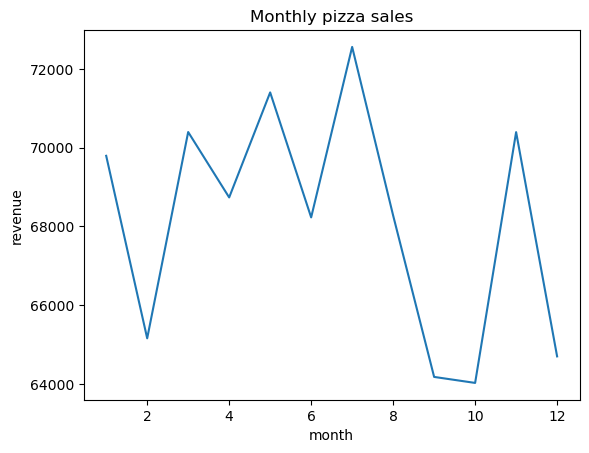

In [75]:
plt.plot(monthly_sales["month"], monthly_sales["revenue"])
plt.title("Monthly pizza sales")
plt.xlabel("month")
plt.ylabel("revenue")

plt.show()

##### From the plot above, we noticed an ups and downs movement for the sales from the first month to the last month.

##### we noticed the peak sales was made in july which is the 7th month.

##### we noticed a long drop in sales between the 7th month and the 9th month. That is July and September.

##### The month with the least sales is October the 10th month as shown in the plot above.


## Question 10: Are there pizza types that are not doing well on the menu?

### To identify the pizza types with low sales

In [76]:
pizza_type_sales = pizza_place_sales.groupby("pizza_type_id")["revenue"].sum().sort_values(ascending=False).reset_index()

In [77]:
print(pizza_type_sales)

   pizza_type_id   revenue
0       thai_ckn  43434.25
1        bbq_ckn  42768.00
2       cali_ckn  41409.50
3    classic_dlx  38180.50
4     spicy_ital  34831.25
5     southw_ckn  34705.75
6      ital_supr  33476.75
7       hawaiian  32273.25
8    four_cheese  32265.70
9       sicilian  30940.50
10     pepperoni  30161.75
11     the_greek  28454.10
12      mexicana  26780.75
13   five_cheese  26066.50
14  peppr_salami  25529.00
15   ital_cpcllo  25094.00
16    veggie_veg  24374.75
17    prsc_argla  24193.25
18    napolitana  24087.00
19   spinach_fet  23271.25
20      big_meat  22968.00
21   pep_msh_pep  18834.50
22   ckn_alfredo  16900.25
23     ckn_pesto  16701.75
24   soppressata  16425.75
25   ital_veggie  16019.25
26     calabrese  15934.25
27    spin_pesto  15596.00
28  mediterraneo  15360.50
29  spinach_supr  15277.75
30  green_garden  13955.75
31    brie_carre  11588.50


In [78]:
#ten least sold pizza type base on sales are:

pizza_type_sales.tail(10)

,pizza_type_id,revenue
22,ckn_alfredo,16900.25
23,ckn_pesto,16701.75
24,soppressata,16425.75
25,ital_veggie,16019.25
26,calabrese,15934.25
27,spin_pesto,15596.00
28,mediterraneo,15360.50
29,spinach_supr,15277.75
30,green_garden,13955.75
31,brie_carre,11588.50
